In [41]:
import numpy as np
import pandas as pd

In [42]:
df= pd.read_csv(r"C:\Users\HP\Downloads\spam.csv",encoding='latin- 1')

In [43]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5309,ham,"Jolly good! By the way, will give u tickets f...",NaN,NaN,NaN
261,ham,Anyway i'm going shopping on my own now. Cos m...,NaN,NaN,NaN
1291,ham,Hey babe! I saw you came online for a second a...,NaN,NaN,NaN
17,ham,Eh u remember how 2 spell his name... Yes i di...,NaN,NaN,NaN
5377,spam,The current leading bid is 151. To pause this ...,NaN,NaN,NaN


In [44]:
df.shape

(5572, 5)

1. Data cleaning

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [46]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [47]:
df.sample(5)

,v1,v2
2781,ham,Then its most likely called Mittelschmertz. Go...
3837,ham,Went to pay rent. So i had to go to the bank t...
4665,ham,Not..tel software name..
3683,ham,Dad says hurry the hell up
3150,ham,Yeah but which is worse for i


Renaming columns

In [48]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(4)

,target,text
5552,ham,Have a safe trip to Nigeria. Wish you happines...
5303,ham,"I can. But it will tell quite long, cos i have..."
3916,ham,Eh ur laptop got no stock lei... He say mon mu...
3453,ham,I dont have any of your file in my bag..i was ...


In [49]:
from sklearn.preprocessing import LabelEncoder 
encoder=LabelEncoder()

In [50]:
df['target']=encoder.fit_transform(df['target'])

In [51]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [52]:
##Missing value check
df.isnull().sum()

target    0
text      0
dtype: int64

In [53]:
##check duplicate value
df.duplicated().sum()

np.int64(403)

In [54]:
##remove duplicate value
df=df.drop_duplicates(keep='first')

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.shape

(5169, 2)

2. EDA

In [57]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

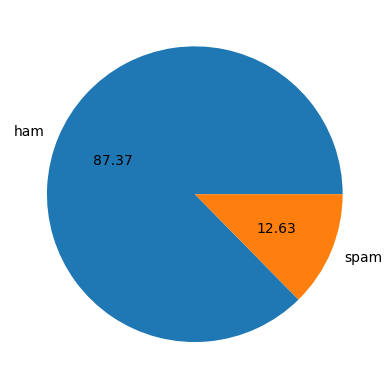

In [58]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [59]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [60]:
import nltk

In [61]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [62]:
df['num_character']=df['text'].apply(len)

In [63]:
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [64]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [65]:
df['text_size']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [66]:
df.head()

,target,text,num_character,text_size
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [67]:
df['num_sentance']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [68]:
df.head()

,target,text,num_character,text_size,num_sentance
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [69]:
df[['num_character','text_size','num_sentance']].describe()

,num_character,text_size,num_sentance
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [70]:
## ham message
df[df['target'] == 0][['num_character','text_size','num_sentance']].describe()

,num_character,text_size,num_sentance
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [71]:
## Spam message
df[df['target'] == 1][['num_character','text_size','num_sentance']].describe()

,num_character,text_size,num_sentance
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_character', ylabel='Count'>

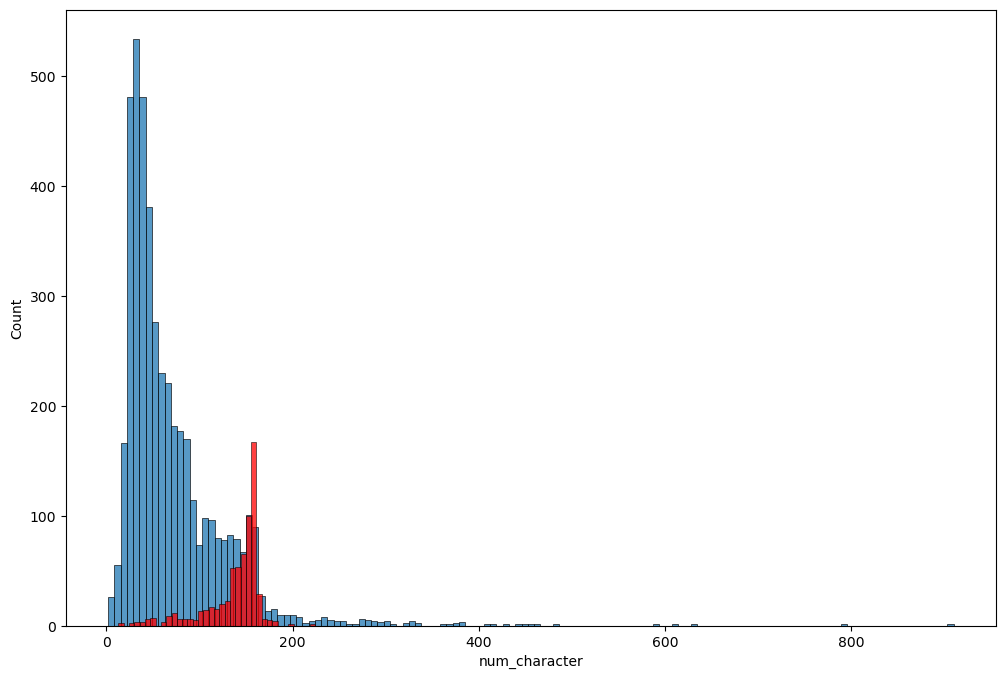

In [72]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['num_character'])
sns.histplot(df[df['target'] == 1]['num_character'], color='red')

<Axes: xlabel='text_size', ylabel='Count'>

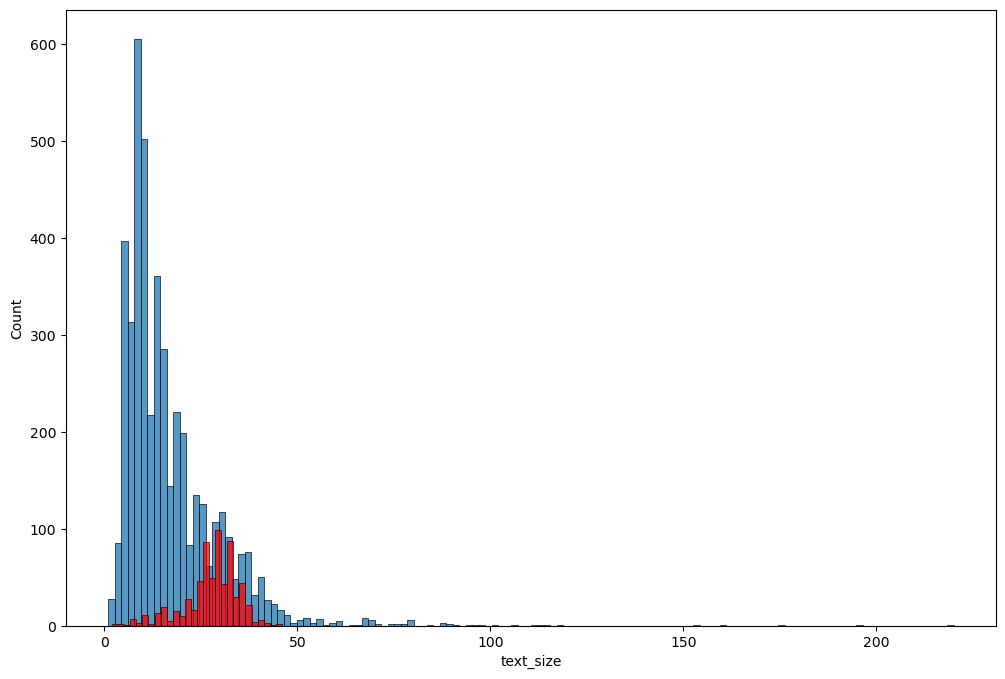

In [73]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['text_size'])
sns.histplot(df[df['target'] == 1]['text_size'], color='red')

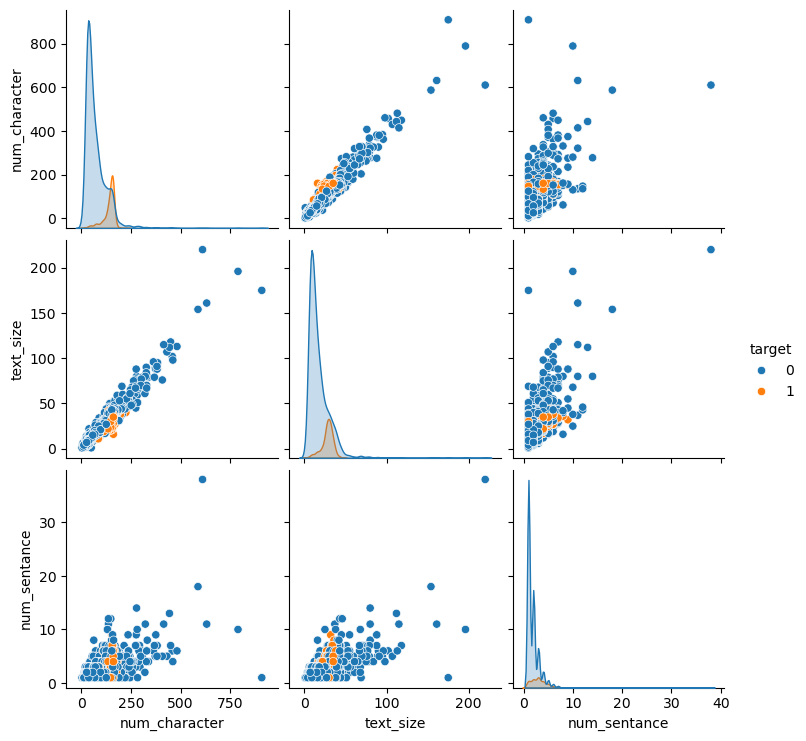

In [74]:
sns.pairplot(df,hue='target')

In [94]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [95]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text= y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    
    return " ".join(y)
    

In [97]:
 transform_text("hey i looking yt channal from machine learning&^")

'hey look yt channal machin learn'

In [98]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('loving')

'love'

In [99]:
from nltk.corpus import stopwords
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [100]:
df['transform_text']=df['text'].apply(transform_text)

In [101]:
df.head()

,target,text,num_character,text_size,num_sentance,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [102]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [103]:
import sys
!{sys.executable} -m pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [104]:
from wordcloud import WordCloud

# Fixed the spelling of background_color
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [105]:
spam_wc = wc.generate(df[df['target'] == 1]['transform_text'].str.cat(sep=" "))

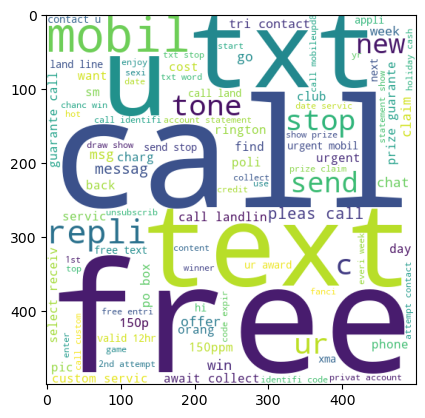

In [107]:
plt.imshow(spam_wc)

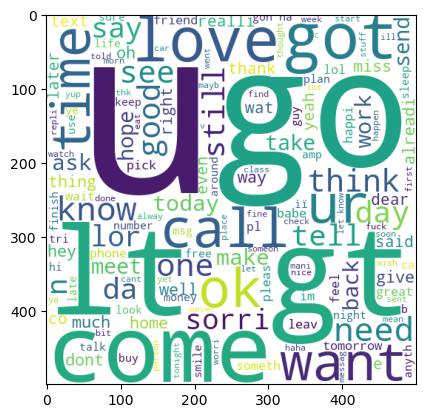

In [108]:
ham_wc = wc.generate(df[df['target'] == 0]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

In [121]:
spam_corpus = []
for msg in df[df['target'] == 1]['transform_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [122]:
len(spam_corpus)

9939

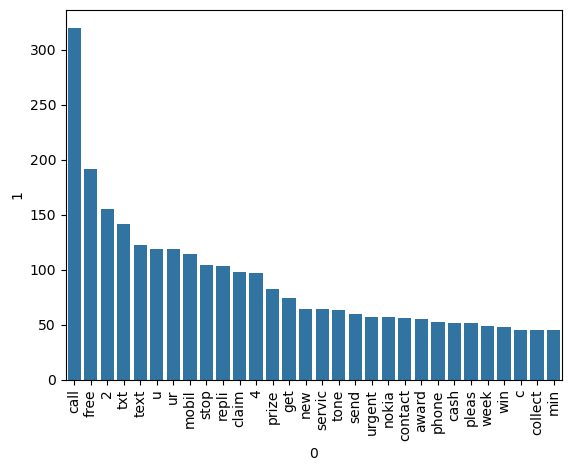

In [127]:
from collections import Counter

# 1. Create the dataframe first
most_common_df = pd.DataFrame(Counter(spam_corpus).most_common(30))

# 2. Use 'x' and 'y' to define the columns
sns.barplot(data=most_common_df, x=most_common_df[0], y=most_common_df[1])

# 3. Rotate the x-labels so they don't overlap
plt.xticks(rotation='vertical')
plt.show()


In [128]:
ham_corpus = []
for msg in df[df['target'] == 0]['transform_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [129]:
len(spam_corpus)

9939

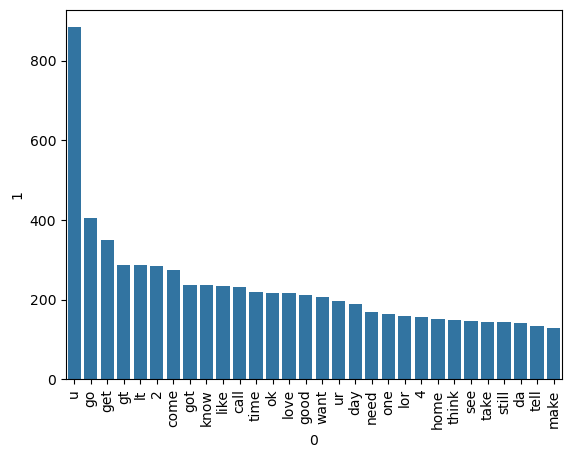

In [131]:
# 1. Create the dataframe first
most_common_df = pd.DataFrame(Counter(ham_corpus).most_common(30))

# 2. Use 'x' and 'y' to define the columns
sns.barplot(data=most_common_df, x=most_common_df[0], y=most_common_df[1])

# 3. Rotate the x-labels so they don't overlap
plt.xticks(rotation='vertical')
plt.show()